# Understanding the data

In [3]:
import pandas
import matplotlib.pyplot as plt

In [4]:
dataFrame = pandas.read_csv("../data/raw/teleco-churn-data.csv")

In [79]:
dataFrame.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
dataFrame.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
dataFrame.shape

(7043, 21)

In [6]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
dataFrame.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
dataFrame.groupby("Churn")["customerID"].count() / len(dataFrame) * 100

Churn
No     73.463013
Yes    26.536987
Name: customerID, dtype: float64

We know that there are $73.6\%$ of customers did not churn in this dataset. In oppesite $26.5\%$ of the customers did actually churn. 

In [9]:
churnedCustomers = dataFrame[dataFrame["Churn"] == "Yes"] # Getting the customers who churn
stayedCustomers = dataFrame[dataFrame["Churn"] == "No"] # Getting the customers who stayed.


# Checking if spliting by the churn was valid, and did not miss any raw.
len(churnedCustomers) + len(stayedCustomers) == len(dataFrame)

True

In [10]:
churnedCustomers.groupby("Contract")["customerID"].count() / len(churnedCustomers) * 100

Contract
Month-to-month    88.550027
One year           8.881755
Two year           2.568218
Name: customerID, dtype: float64

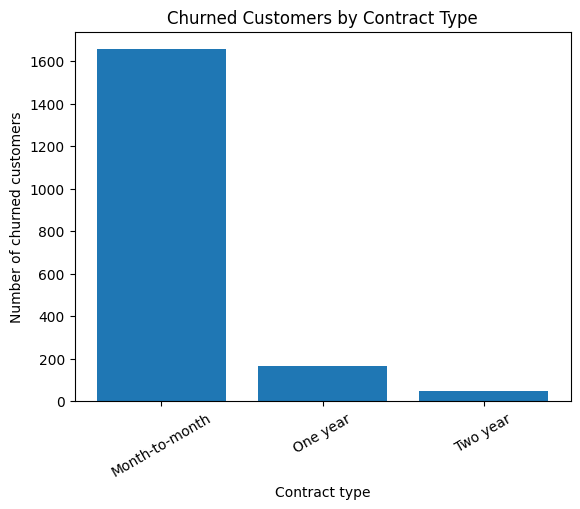

In [11]:
contract_counts = churnedCustomers.groupby("Contract")["customerID"].count()


plt.bar(contract_counts.index, contract_counts.values) #type: ignore
plt.xlabel("Contract type")
plt.ylabel("Number of churned customers")
plt.title("Churned Customers by Contract Type")
plt.xticks(rotation=30)
plt.show()

In [92]:
(dataFrame["Churn"] == "Yes").groupby(dataFrame["Contract"]).mean() * 100


Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

By looking at the figure and numbers above, we can state that most of the customers who did churn, they has month-to-month contracts.

In [12]:
# Saperating each contract type

monthly = dataFrame[dataFrame["Contract"] == "Month-to-month"]
oneYear = dataFrame[dataFrame["Contract"] == "One year"]
twoYears = dataFrame[dataFrame["Contract"] == "Two year"]

In [94]:
pandas.crosstab(dataFrame["Churn"], dataFrame["Contract"], normalize="index")

Contract,Month-to-month,One year,Two year
Churn,,,
No,0.429068,0.252609,0.318322
Yes,0.885500,0.088818,0.025682


In [13]:
monthlyByChurn = monthly.groupby("Churn")["customerID"].count()
oneYearByChurn = oneYear.groupby("Churn")["customerID"].count()
twoYearsByChurn = twoYears.groupby("Churn")["customerID"].count()

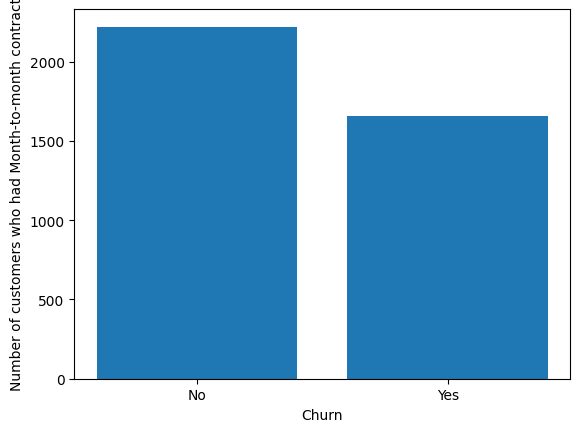

In [14]:
plt.bar(monthlyByChurn.index, monthlyByChurn.values) #type: ignore
plt.ylabel("Number of customers who had Month-to-month contract")
plt.xlabel("Churn")
plt.show()

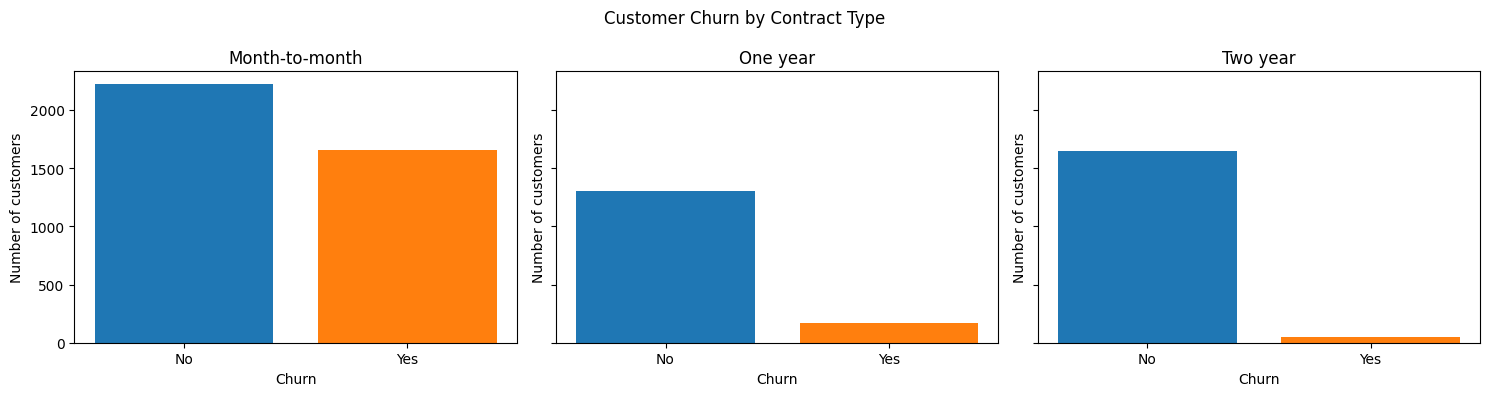

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

churn_counts = [
    (monthlyByChurn, "Month-to-month"),
    (oneYearByChurn, "One year"),
    (twoYearsByChurn, "Two year"),
]

for ax, (counts, contract_type) in zip(axes, churn_counts):
    ax.bar(counts.index, counts.values, color=["tab:blue", "tab:orange"])
    ax.set_title(contract_type)
    ax.set_xlabel("Churn")
    ax.set_ylabel("Number of customers")

fig.suptitle("Customer Churn by Contract Type")
plt.tight_layout()
plt.savefig(fname="../reports/figures/customer-churn-by-cuntract-type.png")
plt.show()

In [16]:
dataFrame.groupby("Contract")["customerID"].count() / len(dataFrame) * 100

Contract
Month-to-month    55.019168
One year          20.914383
Two year          24.066449
Name: customerID, dtype: float64

In [43]:
churnRateByContract = {
    "monthly": {
        "Yes": (monthly[monthly["Churn"] == "Yes"]["customerID"].count() / len(dataFrame) * 100).round(2),
        "No": (monthly[monthly["Churn"] == "No"]["customerID"].count() / len(dataFrame) * 100).round(2)
    },
    "one-year": {
        "Yes": (oneYear[oneYear["Churn"] == "Yes"]["customerID"].count() / len(dataFrame) * 100).round(2),
        "No": (oneYear[oneYear["Churn"] == "No"]["customerID"].count() / len(dataFrame) * 100).round(2)
    },
    "two-year": {
        "Yes": (twoYears[twoYears["Churn"] == "Yes"]["customerID"].count() / len(dataFrame) * 100).round(2),
        "No": (twoYears[twoYears["Churn"] == "No"]["customerID"].count() / len(dataFrame) * 100).round(2)
    }
}
churnRateByContract

{'monthly': {'Yes': 23.5, 'No': 31.52},
 'one-year': {'Yes': 2.36, 'No': 18.56},
 'two-year': {'Yes': 0.68, 'No': 23.38}}

In [67]:
# Check the dictionary validity
rateCounter = 0.0
for contract in churnRateByContract.values():
    for churnValue, rate in contract.items():
        rateCounter += rate
rateCounter

100.0

In [70]:
dataFrame.groupby("Contract")["MonthlyCharges"].mean()

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

In [73]:
stayedCustomers["MonthlyCharges"].mean()

61.26512369540008

In [74]:
churnedCustomers["MonthlyCharges"].mean()

74.44133226324237

In [78]:
stayedCustomers["tenure"].mean(), churnedCustomers["tenure"].mean()

(37.56996521066873, 17.979133226324237)

In [84]:
stayedCustomers[stayedCustomers["gender"] == "Male"]["customerID"].count() / len(stayedCustomers) * 100

50.73444143795902

In [85]:
stayedCustomers[stayedCustomers["gender"] == "Female"]["customerID"].count() / len(stayedCustomers) * 100

49.26555856204097

In [88]:
churnedCustomers[churnedCustomers["gender"] == "Male"]["customerID"].count() / len(churnedCustomers) * 100

49.75922953451043

In [89]:
churnedCustomers[churnedCustomers["gender"] == "Female"]["customerID"].count() / len(churnedCustomers) * 100

50.24077046548957

The gender is not a factor that effects a customers to stayed or churned. Hence:
- Stayed females: $49.24\%$
- Stayed males: $50.73\%$
- Churned females: $50.24\%$
- Churned males: $49.75\%$